In [3]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
TOPOLOGY = "scale_free"
JOB_ARRAY = "job_array_20303860"

BASE_DIR = Path("delays_collected") / TOPOLOGY / JOB_ARRAY
BASE_DIR.exists(), BASE_DIR

(True, PosixPath('delays_collected/scale_free/job_array_20303860'))

In [8]:
from json import JSONDecoder, JSONDecodeError

bad_files = []

for json_path in BASE_DIR.rglob("W* Imigrants.json"):
    try:
        _ = json.loads(json_path.read_text())
    except JSONDecodeError as e:
        bad_files.append((json_path, str(e)))

len(bad_files), bad_files[:5]

(3,
 [(PosixPath('delays_collected/scale_free/job_array_20303860/scale_free_task_0/logs/W188 Imigrants.json'),
   'Extra data: line 1 column 72046 (char 72045)'),
  (PosixPath('delays_collected/scale_free/job_array_20303860/scale_free_task_0/logs/W41 Imigrants.json'),
   'Expecting value: line 1 column 1 (char 0)'),
  (PosixPath('delays_collected/scale_free/job_array_20303860/scale_free_task_0/logs/W53 Imigrants.json'),
   'Expecting value: line 1 column 65537 (char 65536)')])

## 1. Wczytanie opóźnień

In [9]:
def parse_task_id(task_dir: Path) -> int:
    match = re.search(r"_task_(\d+)", task_dir.name)
    return int(match.group(1)) if match else None


def parse_island_id(path: Path) -> int:
    match = re.search(r"W(\d+)", path.name)
    return int(match.group(1)) if match else None


def safe_load_json(path: Path):
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        return None


def load_delay_logs(base_dir: Path, topology: str, job_array: str):
    rows = []
    bad_json_files = []

    task_dirs = sorted(base_dir.glob(f"{topology}_task_*"))

    for task_dir in task_dirs:
        task_id = parse_task_id(task_dir)
        logs_dir = task_dir / "logs"

        for json_path in sorted(logs_dir.glob("W* Imigrants.json")):
            dest_island = parse_island_id(json_path)
            data = safe_load_json(json_path)

            if data is None:
                bad_json_files.append(json_path)
                continue

            for _, record in data.items():
                recv_step = record["step"]
                recv_eval = record["ev"]
                dest_timestamp = record.get("destinTimestamp")
                dest_max_fitness = record.get("destinMaxFitness")

                n = len(record.get("delay_evals", []))

                for i in range(n):
                    rows.append({
                        "topology": topology,
                        "job_array": job_array,
                        "task_id": task_id,
                        "dest_island": dest_island,

                        "recv_step": recv_step,
                        "recv_eval": recv_eval,
                        "dest_timestamp": dest_timestamp,
                        "dest_max_fitness": dest_max_fitness,

                        "src_island": record["src_islands"][i],
                        "send_step": record["iteration_numbers"][i],
                        "send_timestamp": record["timestamps"][i],
                        "migrant_fitness": record["fitnesses"][i],

                        "delay_eval": record["delay_evals"][i],
                        "delay_steps": record["delay_steps"][i],
                        "delay_seconds": record["delay_seconds"][i],
                    })

    df = pd.DataFrame(rows)

    df["abs_delay_eval"] = df["delay_eval"].abs()
    df["abs_delay_steps"] = df["delay_steps"].abs()

    df["delay_sign"] = np.select(
        [
            df["delay_eval"] > 0,
            df["delay_eval"] < 0,
            df["delay_eval"] == 0,
        ],
        [
            "positive_receiver_ahead",
            "negative_sender_ahead",
            "zero",
        ],
        default="unknown"
    )

    return df, bad_json_files

In [10]:
df_delays, bad_json_files = load_delay_logs(BASE_DIR, TOPOLOGY, JOB_ARRAY)

df_delays.shape

(3524862, 18)

In [11]:
len(bad_json_files), bad_json_files

(3,
 [PosixPath('delays_collected/scale_free/job_array_20303860/scale_free_task_0/logs/W188 Imigrants.json'),
  PosixPath('delays_collected/scale_free/job_array_20303860/scale_free_task_0/logs/W41 Imigrants.json'),
  PosixPath('delays_collected/scale_free/job_array_20303860/scale_free_task_0/logs/W53 Imigrants.json')])

In [13]:
df_delays.head()

,topology,job_array,task_id,dest_island,recv_step,recv_eval,dest_timestamp,dest_max_fitness,src_island,send_step,send_timestamp,migrant_fitness,delay_eval,delay_steps,delay_seconds,abs_delay_eval,abs_delay_steps,delay_sign
0,scale_free,job_array_20303860,0,0,2,20,1.780430e+09,3419.568331,480,1,1.780430e+09,3667.263042,4,1,0.249938,4,1,positive_receiver_ahead
1,scale_free,job_array_20303860,0,0,2,20,1.780430e+09,3419.568331,414,1,1.780430e+09,3595.031760,4,1,0.245089,4,1,positive_receiver_ahead
2,scale_free,job_array_20303860,0,0,2,20,1.780430e+09,3419.568331,83,5,1.780430e+09,3485.779808,-12,-3,0.207525,12,3,negative_sender_ahead
3,scale_free,job_array_20303860,0,0,2,20,1.780430e+09,3419.568331,414,7,1.780430e+09,3407.325259,-20,-5,0.204027,20,5,negative_sender_ahead
4,scale_free,job_array_20303860,0,0,2,20,1.780430e+09,3419.568331,453,5,1.780430e+09,3397.292077,-12,-3,0.205646,12,3,negative_sender_ahead


## 2. Wczytanie wyników result.csv

In [14]:
def load_results(base_dir: Path, topology: str, job_array: str) -> pd.DataFrame:
    rows = []

    task_dirs = sorted(base_dir.glob(f"{topology}_task_*"))

    for task_dir in task_dirs:
        task_id = parse_task_id(task_dir)
        result_path = task_dir / "result.csv"

        if not result_path.exists():
            print(f"Missing result.csv: {result_path}")
            continue

        result = pd.read_csv(result_path)

        # Zakładamy, że result.csv ma jeden wiersz.
        # Jeśli ma więcej, bierzemy ostatni.
        row = result.iloc[-1].to_dict()

        row["topology"] = topology
        row["job_array"] = job_array
        row["task_id"] = task_id

        rows.append(row)

    return pd.DataFrame(rows)

In [15]:
df_results = load_results(BASE_DIR, TOPOLOGY, JOB_ARRAY)

df_results.shape

(9, 12)

In [18]:
df_results

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,job_array,task_id
0,0,scale_free,500,5,5,20,19,123,176.397841,25.330563,job_array_20303860,0
1,1,scale_free,500,5,5,20,19,123,108.683845,23.593562,job_array_20303860,1
2,2,scale_free,500,5,5,20,19,123,102.282688,26.103940,job_array_20303860,2
3,3,scale_free,500,5,5,10,4,123,105.045979,23.593562,job_array_20303860,3
4,4,scale_free,500,5,5,10,4,123,385.887296,84.290586,job_array_20303860,4
5,5,scale_free,500,5,5,10,4,123,413.853453,80.722538,job_array_20303860,5
6,6,scale_free,500,5,5,3,2,123,1084.393205,204.553269,job_array_20303860,6
7,7,scale_free,500,5,5,3,2,123,1026.420370,179.195848,job_array_20303860,7
8,8,scale_free,500,5,5,3,2,123,1094.934145,211.663166,job_array_20303860,8


In [17]:
df_results.columns

Index(['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants',
       'migration_interval', 'm0', 'm', 'seed', 'average', 'best', 'job_array',
       'task_id'],
      dtype='object')

## 3. Agregacja opóźnień per task

In [19]:
delay_by_task = (
    df_delays
    .groupby(["topology", "job_array", "task_id"], as_index=False)
    .agg(
        n_migrants=("delay_eval", "size"),

        mean_delay_steps=("delay_steps", "mean"),
        median_delay_steps=("delay_steps", "median"),
        std_delay_steps=("delay_steps", "std"),
        mean_abs_delay_steps=("abs_delay_steps", "mean"),
        median_abs_delay_steps=("abs_delay_steps", "median"),
        q95_abs_delay_steps=("abs_delay_steps", lambda x: x.quantile(0.95)),
        max_abs_delay_steps=("abs_delay_steps", "max"),

        mean_delay_eval=("delay_eval", "mean"),
        median_delay_eval=("delay_eval", "median"),
        std_delay_eval=("delay_eval", "std"),
        mean_abs_delay_eval=("abs_delay_eval", "mean"),
        median_abs_delay_eval=("abs_delay_eval", "median"),
        q95_abs_delay_eval=("abs_delay_eval", lambda x: x.quantile(0.95)),
        max_abs_delay_eval=("abs_delay_eval", "max"),

        mean_delay_seconds=("delay_seconds", "mean"),
        median_delay_seconds=("delay_seconds", "median"),
        q95_delay_seconds=("delay_seconds", lambda x: x.quantile(0.95)),

        share_positive_delay_eval=("delay_eval", lambda x: (x > 0).mean()),
        share_negative_delay_eval=("delay_eval", lambda x: (x < 0).mean()),
        share_zero_delay_eval=("delay_eval", lambda x: (x == 0).mean()),
    )
)

delay_by_task

,topology,job_array,task_id,n_migrants,mean_delay_steps,median_delay_steps,std_delay_steps,mean_abs_delay_steps,median_abs_delay_steps,q95_abs_delay_steps,...,mean_abs_delay_eval,median_abs_delay_eval,q95_abs_delay_eval,max_abs_delay_eval,mean_delay_seconds,median_delay_seconds,q95_delay_seconds,share_positive_delay_eval,share_negative_delay_eval,share_zero_delay_eval
0,scale_free,job_array_20303860,0,393057,-101.980072,-85.0,122.561910,123.840606,99.0,316.0,...,495.362423,396.0,1264.0,1464,3.020408,1.133200,10.454961,0.188108,0.806326,0.005567
1,scale_free,job_array_20303860,1,415223,-105.544931,-89.0,123.057990,126.249001,102.0,319.0,...,504.996005,408.0,1276.0,1464,3.375203,1.362697,11.651584,0.180226,0.814122,0.005652
2,scale_free,job_array_20303860,2,378209,-97.554707,-80.0,121.832056,120.381519,95.0,313.0,...,481.526077,380.0,1252.0,1456,2.755881,0.852158,10.208564,0.198731,0.795354,0.005915
3,scale_free,job_array_20303860,3,401939,-102.585494,-86.0,122.624427,124.077173,99.0,317.0,...,496.308694,396.0,1268.0,1464,3.150332,1.150667,11.267211,0.187329,0.806946,0.005725
4,scale_free,job_array_20303860,4,381600,-123.176208,-114.0,122.846508,139.574541,123.0,326.0,...,558.298166,492.0,1304.0,1464,4.165733,2.913024,12.082880,0.135841,0.859091,0.005068
5,scale_free,job_array_20303860,5,382401,-125.581194,-115.0,123.211993,141.294202,123.0,329.0,...,565.176807,492.0,1316.0,1468,4.174379,2.963996,12.099550,0.125036,0.870327,0.004636
6,scale_free,job_array_20303860,6,390688,-143.449387,-139.0,120.039338,154.076900,144.0,334.0,...,616.307601,576.0,1336.0,1468,5.102330,4.670864,12.101239,0.084781,0.911164,0.004054
7,scale_free,job_array_20303860,7,390105,-135.974066,-131.0,120.544487,148.791092,138.0,327.0,...,595.164369,552.0,1308.0,1464,4.815783,4.381306,11.813351,0.107609,0.888412,0.003978
8,scale_free,job_array_20303860,8,391640,-140.198672,-136.0,120.680569,151.949775,142.0,331.0,...,607.799101,568.0,1324.0,1464,5.075876,4.660103,12.114900,0.097048,0.898282,0.004670


## 4. Połączenie opóźnień z wynikami fitness

In [20]:
analysis_df = delay_by_task.merge(
    df_results,
    on=["topology", "job_array", "task_id"],
    how="left"
)

analysis_df

,topology,job_array,task_id,n_migrants,mean_delay_steps,median_delay_steps,std_delay_steps,mean_abs_delay_steps,median_abs_delay_steps,q95_abs_delay_steps,...,share_zero_delay_eval,array_task_id,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best
0,scale_free,job_array_20303860,0,393057,-101.980072,-85.0,122.561910,123.840606,99.0,316.0,...,0.005567,0,500,5,5,20,19,123,176.397841,25.330563
1,scale_free,job_array_20303860,1,415223,-105.544931,-89.0,123.057990,126.249001,102.0,319.0,...,0.005652,1,500,5,5,20,19,123,108.683845,23.593562
2,scale_free,job_array_20303860,2,378209,-97.554707,-80.0,121.832056,120.381519,95.0,313.0,...,0.005915,2,500,5,5,20,19,123,102.282688,26.103940
3,scale_free,job_array_20303860,3,401939,-102.585494,-86.0,122.624427,124.077173,99.0,317.0,...,0.005725,3,500,5,5,10,4,123,105.045979,23.593562
4,scale_free,job_array_20303860,4,381600,-123.176208,-114.0,122.846508,139.574541,123.0,326.0,...,0.005068,4,500,5,5,10,4,123,385.887296,84.290586
5,scale_free,job_array_20303860,5,382401,-125.581194,-115.0,123.211993,141.294202,123.0,329.0,...,0.004636,5,500,5,5,10,4,123,413.853453,80.722538
6,scale_free,job_array_20303860,6,390688,-143.449387,-139.0,120.039338,154.076900,144.0,334.0,...,0.004054,6,500,5,5,3,2,123,1084.393205,204.553269
7,scale_free,job_array_20303860,7,390105,-135.974066,-131.0,120.544487,148.791092,138.0,327.0,...,0.003978,7,500,5,5,3,2,123,1026.420370,179.195848
8,scale_free,job_array_20303860,8,391640,-140.198672,-136.0,120.680569,151.949775,142.0,331.0,...,0.004670,8,500,5,5,3,2,123,1094.934145,211.663166


## 5. Reprodukcja artykułu: delay_steps

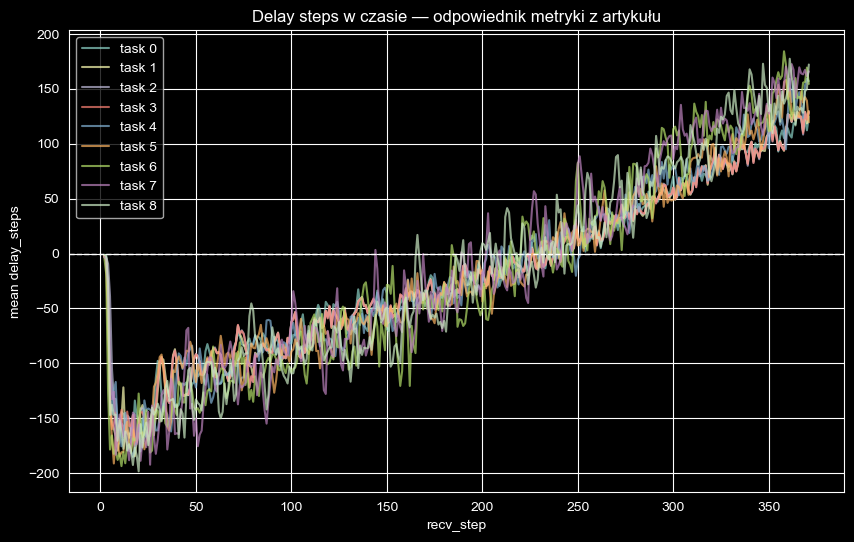

In [21]:
delay_steps_time = (
    df_delays
    .groupby(["task_id", "recv_step"], as_index=False)
    .agg(mean_delay_steps=("delay_steps", "mean"))
)

plt.figure(figsize=(10, 6))

for task_id, group in delay_steps_time.groupby("task_id"):
    plt.plot(group["recv_step"], group["mean_delay_steps"], alpha=0.7, label=f"task {task_id}")

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("recv_step")
plt.ylabel("mean delay_steps")
plt.title("Delay steps w czasie — odpowiednik metryki z artykułu")
plt.legend()
plt.grid(True)
plt.show()

## 6. Własna analiza: delay_eval

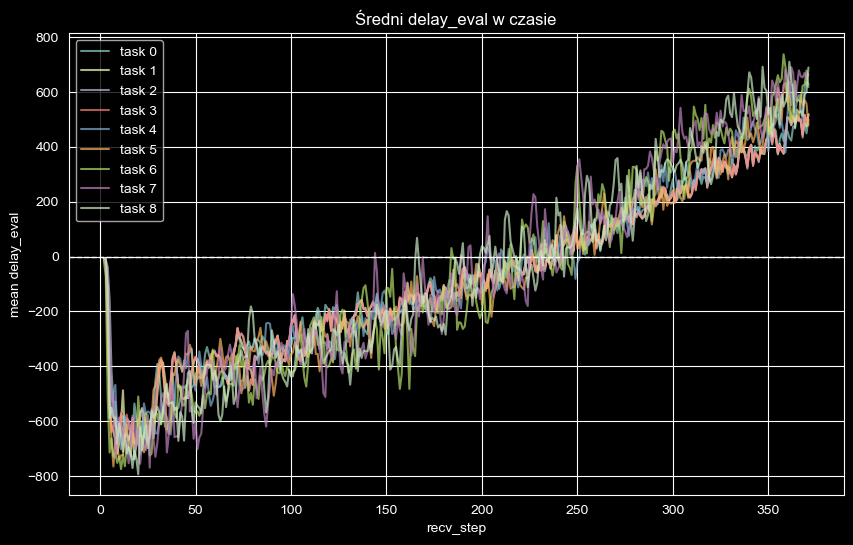

In [22]:
delay_eval_time = (
    df_delays
    .groupby(["task_id", "recv_step"], as_index=False)
    .agg(mean_delay_eval=("delay_eval", "mean"))
)

plt.figure(figsize=(10, 6))

for task_id, group in delay_eval_time.groupby("task_id"):
    plt.plot(group["recv_step"], group["mean_delay_eval"], alpha=0.7, label=f"task {task_id}")

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("recv_step")
plt.ylabel("mean delay_eval")
plt.title("Średni delay_eval w czasie")
plt.legend()
plt.grid(True)
plt.show()

## 7. Wykres abs(delay_eval)

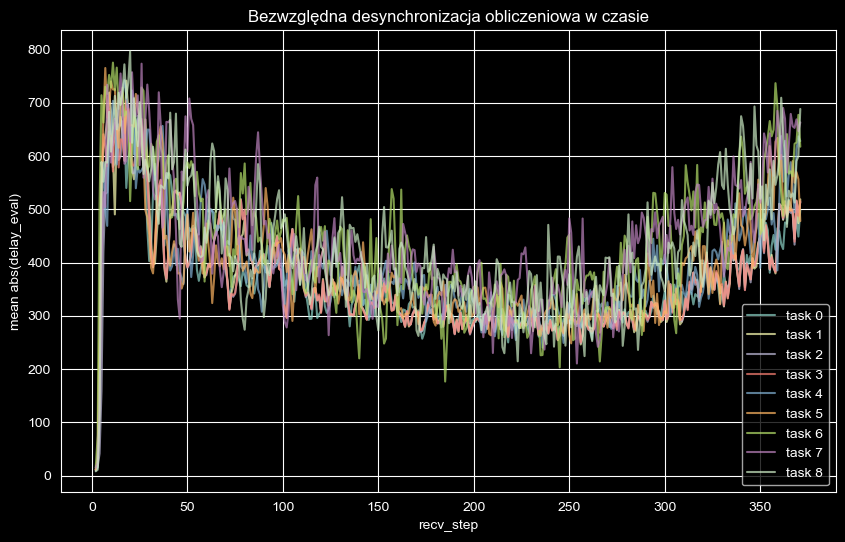

In [23]:
abs_delay_eval_time = (
    df_delays
    .groupby(["task_id", "recv_step"], as_index=False)
    .agg(mean_abs_delay_eval=("abs_delay_eval", "mean"))
)

plt.figure(figsize=(10, 6))

for task_id, group in abs_delay_eval_time.groupby("task_id"):
    plt.plot(group["recv_step"], group["mean_abs_delay_eval"], alpha=0.7, label=f"task {task_id}")

plt.xlabel("recv_step")
plt.ylabel("mean abs(delay_eval)")
plt.title("Bezwzględna desynchronizacja obliczeniowa w czasie")
plt.legend()
plt.grid(True)
plt.show()

## 8. Histogramy

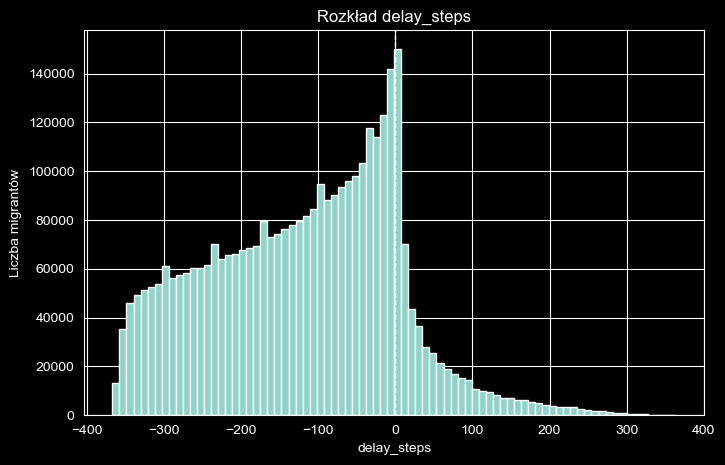

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(df_delays["delay_steps"], bins=80)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("delay_steps")
plt.ylabel("Liczba migrantów")
plt.title("Rozkład delay_steps")
plt.grid(True)
plt.show()


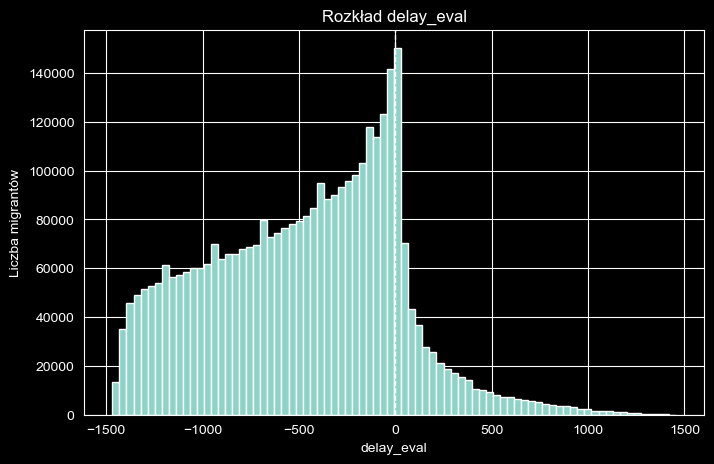

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(df_delays["delay_eval"], bins=80)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("delay_eval")
plt.ylabel("Liczba migrantów")
plt.title("Rozkład delay_eval")
plt.grid(True)
plt.show()

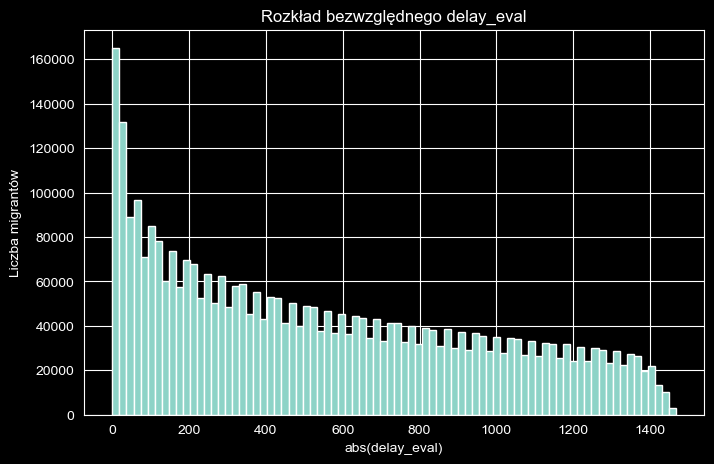

In [26]:
plt.figure(figsize=(8, 5))
plt.hist(df_delays["abs_delay_eval"], bins=80)
plt.xlabel("abs(delay_eval)")
plt.ylabel("Liczba migrantów")
plt.title("Rozkład bezwzględnego delay_eval")
plt.grid(True)
plt.show()

## 9. Zestawienie z wynikami fitness

In [28]:
analysis_df[[
    "task_id",
    "n_migrants",
    "mean_abs_delay_eval",
    "median_abs_delay_eval",
    "q95_abs_delay_eval",
    "mean_abs_delay_steps",
    "best",
    "average",
]]

,task_id,n_migrants,mean_abs_delay_eval,median_abs_delay_eval,q95_abs_delay_eval,mean_abs_delay_steps,best,average
0,0,393057,495.362423,396.0,1264.0,123.840606,25.330563,176.397841
1,1,415223,504.996005,408.0,1276.0,126.249001,23.593562,108.683845
2,2,378209,481.526077,380.0,1252.0,120.381519,26.103940,102.282688
3,3,401939,496.308694,396.0,1268.0,124.077173,23.593562,105.045979
4,4,381600,558.298166,492.0,1304.0,139.574541,84.290586,385.887296
5,5,382401,565.176807,492.0,1316.0,141.294202,80.722538,413.853453
6,6,390688,616.307601,576.0,1336.0,154.076900,204.553269,1084.393205
7,7,390105,595.164369,552.0,1308.0,148.791092,179.195848,1026.420370
8,8,391640,607.799101,568.0,1324.0,151.949775,211.663166,1094.934145


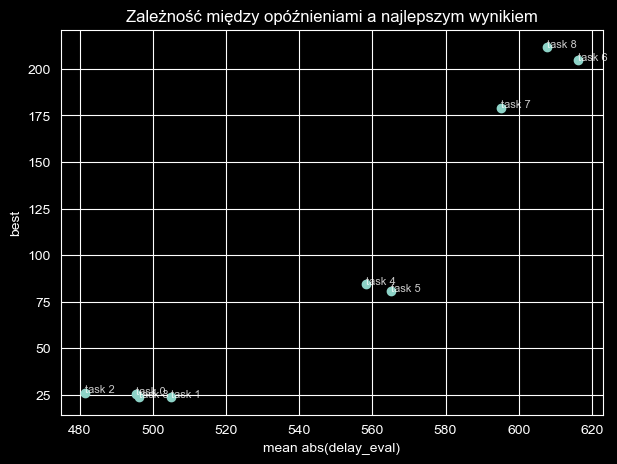

In [30]:
plt.figure(figsize=(7, 5))

plt.scatter(
    analysis_df["mean_abs_delay_eval"],
    analysis_df["best"],
)

for _, row in analysis_df.iterrows():
    plt.annotate(
        f"task {int(row['task_id'])}",
        (row["mean_abs_delay_eval"], row["best"]),
        fontsize=8,
        alpha=0.8,
    )

plt.xlabel("mean abs(delay_eval)")
plt.ylabel("best")
plt.title("Zależność między opóźnieniami a najlepszym wynikiem")
plt.grid(True)
plt.show()

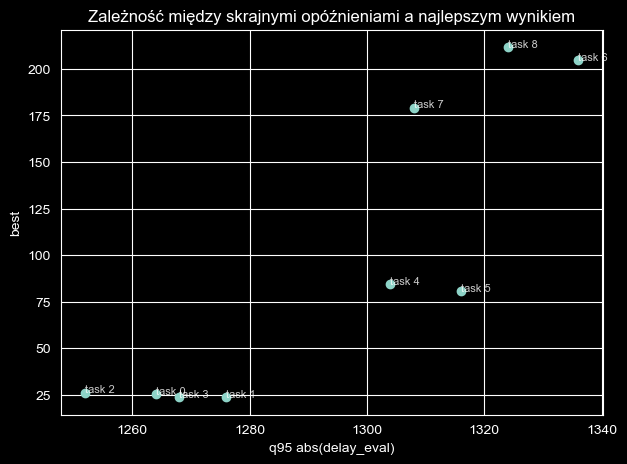

In [32]:
plt.figure(figsize=(7, 5))

plt.scatter(
    analysis_df["q95_abs_delay_eval"],
    analysis_df["best"],
)

for _, row in analysis_df.iterrows():
    plt.annotate(
        f"task {int(row['task_id'])}",
        (row["q95_abs_delay_eval"], row["best"]),
        fontsize=8,
        alpha=0.8,
    )

plt.xlabel("q95 abs(delay_eval)")
plt.ylabel("best")
plt.title("Zależność między skrajnymi opóźnieniami a najlepszym wynikiem")
plt.grid(True)
plt.show()

## 10. Korelacje

In [33]:
corr_cols = [
    "mean_abs_delay_eval",
    "median_abs_delay_eval",
    "q95_abs_delay_eval",
    "max_abs_delay_eval",
    "mean_abs_delay_steps",
    "q95_abs_delay_steps",
    "best",
    "average"
]

analysis_df[corr_cols].corr()

,mean_abs_delay_eval,median_abs_delay_eval,q95_abs_delay_eval,max_abs_delay_eval,mean_abs_delay_steps,q95_abs_delay_steps,best,average
mean_abs_delay_eval,1.000000,0.998432,0.970901,0.593645,1.000000,0.970901,0.958487,0.949231
median_abs_delay_eval,0.998432,1.000000,0.956920,0.555006,0.998432,0.956920,0.969025,0.960556
q95_abs_delay_eval,0.970901,0.956920,1.000000,0.716681,0.970901,1.000000,0.876558,0.857614
max_abs_delay_eval,0.593645,0.555006,0.716681,1.000000,0.593645,0.716681,0.414022,0.422172
mean_abs_delay_steps,1.000000,0.998432,0.970901,0.593645,1.000000,0.970901,0.958487,0.949231
q95_abs_delay_steps,0.970901,0.956920,1.000000,0.716681,0.970901,1.000000,0.876558,0.857614
best,0.958487,0.969025,0.876558,0.414022,0.958487,0.876558,1.000000,0.995793
average,0.949231,0.960556,0.857614,0.422172,0.949231,0.857614,0.995793,1.000000


## 11. Agregacja powtórzeń

In [34]:
analysis_df["config_id"] = analysis_df["task_id"] // 3
df_delays["config_id"] = df_delays["task_id"] // 3

In [36]:
summary_by_config = (
    analysis_df
    .groupby(["topology", "config_id"], as_index=False)
    .agg(
        runs=("task_id", "count"),

        mean_abs_delay_eval=("mean_abs_delay_eval", "mean"),
        std_abs_delay_eval=("mean_abs_delay_eval", "std"),
        mean_q95_abs_delay_eval=("q95_abs_delay_eval", "mean"),

        mean_abs_delay_steps=("mean_abs_delay_steps", "mean"),
        mean_q95_abs_delay_steps=("q95_abs_delay_steps", "mean"),

        best_mean=("best", "mean"),
        best_std=("best", "std"),
        avg_mean=("average", "mean"),
        avg_std=("average", "std"),
    )
)

summary_by_config

,topology,config_id,runs,mean_abs_delay_eval,std_abs_delay_eval,mean_q95_abs_delay_eval,mean_abs_delay_steps,mean_q95_abs_delay_steps,best_mean,best_std,avg_mean,avg_std
0,scale_free,0,3,493.961502,11.797513,1264.000000,123.490375,316.000000,25.009355,1.285644,129.121458,41.067456
1,scale_free,1,3,539.927889,37.931577,1296.000000,134.981972,324.000000,62.868895,34.060191,301.595576,170.790323
2,scale_free,2,3,606.423690,10.638510,1322.666667,151.605923,330.666667,198.470761,17.066908,1068.582573,36.891956


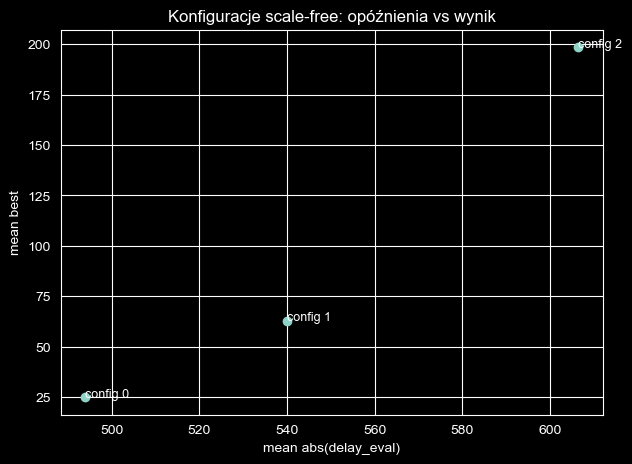

In [39]:
plt.figure(figsize=(7, 5))

plt.scatter(
    summary_by_config["mean_abs_delay_eval"],
    summary_by_config["best_mean"],
)

for _, row in summary_by_config.iterrows():
    plt.annotate(
        f"config {int(row['config_id'])}",
        (row["mean_abs_delay_eval"], row["best_mean"]),
        fontsize=9,
    )

plt.xlabel("mean abs(delay_eval)")
plt.ylabel(f"mean {"best"}")
plt.title("Konfiguracje scale-free: opóźnienia vs wynik")
plt.grid(True)
plt.show()

## 12. Porównanie różnych topologii

In [58]:
DATASETS = [
    ("scale_free", "job_array_20303860"),
    ("meeting", "job_array_20304749"),
    ("complete", "job_array_20315012"),
]

In [59]:
all_delays = []
all_results = []
all_bad_files = []

for topology, job_array in DATASETS:
    base_dir = Path("delays_collected") / topology / job_array

    delays_df, bad_files = load_delay_logs(
        base_dir,
        topology,
        job_array
    )

    results_df = load_results(
        base_dir,
        topology,
        job_array
    )

    all_delays.append(delays_df)
    all_results.append(results_df)

    all_bad_files.extend(
        [
            {
                "topology": topology,
                "job_array": job_array,
                "file": str(f)
            }
            for f in bad_files
        ]
    )

df_delays_all = pd.concat(all_delays, ignore_index=True)
df_results_all = pd.concat(all_results, ignore_index=True)

bad_files_df = pd.DataFrame(all_bad_files)

In [60]:
df_delays_all.shape

(8580204, 18)

In [61]:
df_results_all.shape

(21, 18)

In [62]:
bad_files_df

,topology,job_array,file
0,scale_free,job_array_20303860,delays_collected/scale_free/job_array_20303860...
1,scale_free,job_array_20303860,delays_collected/scale_free/job_array_20303860...
2,scale_free,job_array_20303860,delays_collected/scale_free/job_array_20303860...
3,meeting,job_array_20304749,delays_collected/meeting/job_array_20304749/me...
4,meeting,job_array_20304749,delays_collected/meeting/job_array_20304749/me...
5,meeting,job_array_20304749,delays_collected/meeting/job_array_20304749/me...
6,meeting,job_array_20304749,delays_collected/meeting/job_array_20304749/me...
7,complete,job_array_20315012,delays_collected/complete/job_array_20315012/c...
8,complete,job_array_20315012,delays_collected/complete/job_array_20315012/c...


In [63]:
df_delays_all.groupby("topology").size()

topology
complete      1277090
meeting       3778252
scale_free    3524862
dtype: int64

In [64]:
df_delays_all["abs_delay_eval"] = df_delays_all["delay_eval"].abs()
df_delays_all["abs_delay_steps"] = df_delays_all["delay_steps"].abs()

In [65]:
summary_by_topology = (
    df_delays_all
    .groupby("topology", as_index=False)
    .agg(
        n_migrants=("delay_eval", "size"),
        mean_abs_delay_eval=("abs_delay_eval", "mean"),
        median_abs_delay_eval=("abs_delay_eval", "median"),
        q95_abs_delay_eval=("abs_delay_eval", lambda x: x.quantile(0.95)),
        mean_abs_delay_steps=("abs_delay_steps", "mean"),
        q95_abs_delay_steps=("abs_delay_steps", lambda x: x.quantile(0.95)),
        mean_delay_seconds=("delay_seconds", "mean"),
    )
)

summary_by_topology

,topology,n_migrants,mean_abs_delay_eval,median_abs_delay_eval,q95_abs_delay_eval,mean_abs_delay_steps,q95_abs_delay_steps,mean_delay_seconds
0,complete,1277090,201.488819,156.0,548.0,50.372205,137.0,1.491088
1,meeting,3778252,207.278392,152.0,600.0,51.819598,150.0,0.544854
2,scale_free,3524862,546.451100,472.0,1300.0,136.612775,325.0,3.955650


In [66]:
delay_by_task = (
    df_delays_all
    .groupby(["topology", "job_array", "task_id"], as_index=False)
    .agg(
        n_migrants=("delay_eval", "size"),

        mean_delay_steps=("delay_steps", "mean"),
        median_delay_steps=("delay_steps", "median"),
        std_delay_steps=("delay_steps", "std"),
        mean_abs_delay_steps=("abs_delay_steps", "mean"),
        median_abs_delay_steps=("abs_delay_steps", "median"),
        q95_abs_delay_steps=("abs_delay_steps", lambda x: x.quantile(0.95)),
        max_abs_delay_steps=("abs_delay_steps", "max"),

        mean_delay_eval=("delay_eval", "mean"),
        median_delay_eval=("delay_eval", "median"),
        std_delay_eval=("delay_eval", "std"),
        mean_abs_delay_eval=("abs_delay_eval", "mean"),
        median_abs_delay_eval=("abs_delay_eval", "median"),
        q95_abs_delay_eval=("abs_delay_eval", lambda x: x.quantile(0.95)),
        max_abs_delay_eval=("abs_delay_eval", "max"),

        mean_delay_seconds=("delay_seconds", "mean"),
        median_delay_seconds=("delay_seconds", "median"),
        q95_delay_seconds=("delay_seconds", lambda x: x.quantile(0.95)),

        share_positive_delay_eval=("delay_eval", lambda x: (x > 0).mean()),
        share_negative_delay_eval=("delay_eval", lambda x: (x < 0).mean()),
        share_zero_delay_eval=("delay_eval", lambda x: (x == 0).mean()),
    )
)

delay_by_task

,topology,job_array,task_id,n_migrants,mean_delay_steps,median_delay_steps,std_delay_steps,mean_abs_delay_steps,median_abs_delay_steps,q95_abs_delay_steps,...,mean_abs_delay_eval,median_abs_delay_eval,q95_abs_delay_eval,max_abs_delay_eval,mean_delay_seconds,median_delay_seconds,q95_delay_seconds,share_positive_delay_eval,share_negative_delay_eval,share_zero_delay_eval
0,complete,job_array_20315012,0,423990,16.024503,12.0,56.804652,44.841154,35.0,123.0,...,179.364617,140.0,492.0,1116,1.173670,0.578012,5.196677,0.607368,0.383851,0.008781
1,complete,job_array_20315012,1,428114,17.453092,14.0,68.934229,54.813318,43.0,144.0,...,219.253274,172.0,576.0,1252,1.755990,0.699529,6.021662,0.606348,0.386058,0.007594
2,complete,job_array_20315012,2,424986,17.596671,13.0,64.871568,51.416491,40.0,138.0,...,205.665965,160.0,552.0,1184,1.540909,0.639501,5.872596,0.605389,0.386448,0.008163
3,meeting,job_array_20304749,0,454496,-14.342967,-12.0,53.209876,42.169614,33.0,113.0,...,168.678457,132.0,452.0,1052,0.447082,0.385027,1.218577,0.384976,0.605314,0.009710
4,meeting,job_array_20304749,1,454496,-14.342967,-12.0,53.209876,42.169614,33.0,113.0,...,168.678457,132.0,452.0,1052,0.447082,0.385027,1.218577,0.384976,0.605314,0.009710
5,meeting,job_array_20304749,2,453070,-13.901126,-11.0,53.040005,41.974730,33.0,112.0,...,167.898921,132.0,448.0,1052,0.446306,0.384142,1.217160,0.387673,0.602629,0.009698
6,meeting,job_array_20304749,3,423541,-3.004576,-3.0,61.151478,46.643227,36.0,126.0,...,186.572908,144.0,504.0,1072,0.427055,0.358762,1.176742,0.469801,0.520887,0.009312
7,meeting,job_array_20304749,4,422841,-3.033975,-2.0,58.332177,44.494122,35.0,120.0,...,177.976488,140.0,480.0,1092,0.450759,0.375163,1.282565,0.471054,0.519157,0.009789
8,meeting,job_array_20304749,5,427246,-1.939487,-1.0,51.535630,39.299322,31.0,105.0,...,157.197287,124.0,420.0,1028,0.432884,0.357828,1.233251,0.479770,0.509685,0.010544
9,meeting,job_array_20304749,6,382397,-17.707728,-12.0,96.932812,73.764507,55.0,208.0,...,295.058026,220.0,832.0,1412,0.798808,0.581838,2.312986,0.415424,0.576856,0.007720


In [67]:
analysis_df_all = delay_by_task.merge(
    df_results_all,
    on=["topology", "job_array", "task_id"],
    how="left"
)

analysis_df_all

,topology,job_array,task_id,n_migrants,mean_delay_steps,median_delay_steps,std_delay_steps,mean_abs_delay_steps,median_abs_delay_steps,q95_abs_delay_steps,...,m,seed,average,best,z_star,n_steps,r0,r1,gamma,build_target_ratio
0,complete,job_array_20315012,0,423990,16.024503,12.0,56.804652,44.841154,35.0,123.0,...,NaN,NaN,75.277134,51.342639,NaN,NaN,NaN,NaN,NaN,NaN
1,complete,job_array_20315012,1,428114,17.453092,14.0,68.934229,54.813318,43.0,144.0,...,NaN,NaN,74.870863,52.491222,NaN,NaN,NaN,NaN,NaN,NaN
2,complete,job_array_20315012,2,424986,17.596671,13.0,64.871568,51.416491,40.0,138.0,...,NaN,NaN,74.636607,55.784573,NaN,NaN,NaN,NaN,NaN,NaN
3,meeting,job_array_20304749,0,454496,-14.342967,-12.0,53.209876,42.169614,33.0,113.0,...,NaN,123.0,66.145031,56.975246,10.0,1000.0,0.00050,1.0,0.0050,0.8
4,meeting,job_array_20304749,1,454496,-14.342967,-12.0,53.209876,42.169614,33.0,113.0,...,NaN,123.0,66.131535,55.009490,10.0,1000.0,0.00050,1.0,0.0050,0.8
5,meeting,job_array_20304749,2,453070,-13.901126,-11.0,53.040005,41.974730,33.0,112.0,...,NaN,123.0,71.037815,59.674479,10.0,1000.0,0.00050,1.0,0.0050,0.8
6,meeting,job_array_20304749,3,423541,-3.004576,-3.0,61.151478,46.643227,36.0,126.0,...,NaN,123.0,72.337605,56.752925,10.0,1000.0,0.00100,2.0,0.0005,0.8
7,meeting,job_array_20304749,4,422841,-3.033975,-2.0,58.332177,44.494122,35.0,120.0,...,NaN,123.0,70.643262,56.911435,10.0,1000.0,0.00100,2.0,0.0005,0.8
8,meeting,job_array_20304749,5,427246,-1.939487,-1.0,51.535630,39.299322,31.0,105.0,...,NaN,123.0,74.475084,58.709045,10.0,1000.0,0.00100,2.0,0.0005,0.8
9,meeting,job_array_20304749,6,382397,-17.707728,-12.0,96.932812,73.764507,55.0,208.0,...,NaN,123.0,142.322384,106.774492,5.0,1000.0,0.00025,1.0,0.0005,0.8


In [68]:
analysis_df_all[[
    "topology",
    "task_id",
    "n_migrants",
    "mean_abs_delay_eval",
    "median_abs_delay_eval",
    "q95_abs_delay_eval",
    "mean_abs_delay_steps",
    "best",
    "average",
]]

,topology,task_id,n_migrants,mean_abs_delay_eval,median_abs_delay_eval,q95_abs_delay_eval,mean_abs_delay_steps,best,average
0,complete,0,423990,179.364617,140.0,492.0,44.841154,51.342639,75.277134
1,complete,1,428114,219.253274,172.0,576.0,54.813318,52.491222,74.870863
2,complete,2,424986,205.665965,160.0,552.0,51.416491,55.784573,74.636607
3,meeting,0,454496,168.678457,132.0,452.0,42.169614,56.975246,66.145031
4,meeting,1,454496,168.678457,132.0,452.0,42.169614,55.009490,66.131535
5,meeting,2,453070,167.898921,132.0,448.0,41.974730,59.674479,71.037815
6,meeting,3,423541,186.572908,144.0,504.0,46.643227,56.752925,72.337605
7,meeting,4,422841,177.976488,140.0,480.0,44.494122,56.911435,70.643262
8,meeting,5,427246,157.197287,124.0,420.0,39.299322,58.709045,74.475084
9,meeting,6,382397,295.058026,220.0,832.0,73.764507,106.774492,142.322384


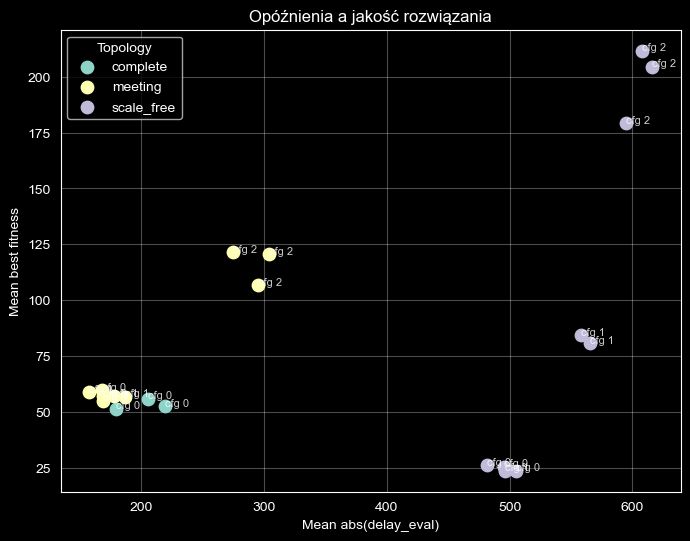

In [73]:
plt.figure(figsize=(8, 6))

for topology, group in analysis_df_all.groupby("topology"):
    plt.scatter(
        group["mean_abs_delay_eval"],
        group["best"],
        label=topology,
        s=80,
    )

    for _, row in group.iterrows():
        plt.annotate(
            f"cfg {int(row['config_id'])}",
            (row["mean_abs_delay_eval"], row["best"]),
            fontsize=8,
            alpha=0.8,
        )

plt.xlabel("Mean abs(delay_eval)")
plt.ylabel("Mean best fitness")
plt.title("Opóźnienia a jakość rozwiązania")
plt.legend(title="Topology")
plt.grid(True, alpha=0.3)
plt.show()

In [69]:
analysis_df_all["config_id"] = analysis_df_all["task_id"] // 3
df_delays_all["config_id"] = df_delays_all["task_id"] // 3
summary_by_config = (
    analysis_df_all
    .groupby(["topology", "config_id"], as_index=False)
    .agg(
        runs=("task_id", "count"),

        mean_abs_delay_eval=("mean_abs_delay_eval", "mean"),
        std_abs_delay_eval=("mean_abs_delay_eval", "std"),
        mean_q95_abs_delay_eval=("q95_abs_delay_eval", "mean"),

        mean_abs_delay_steps=("mean_abs_delay_steps", "mean"),
        mean_q95_abs_delay_steps=("q95_abs_delay_steps", "mean"),

        best_mean=("best", "mean"),
        best_std=("best", "std"),
        avg_mean=("average", "mean"),
        avg_std=("average", "std"),
    )
)

summary_by_config

,topology,config_id,runs,mean_abs_delay_eval,std_abs_delay_eval,mean_q95_abs_delay_eval,mean_abs_delay_steps,mean_q95_abs_delay_steps,best_mean,best_std,avg_mean,avg_std
0,complete,0,3,201.427952,20.279221,540.000000,50.356988,135.000000,53.206145,2.305652,74.928201,0.324090
1,meeting,0,3,168.418612,0.450066,450.666667,42.104653,112.666667,57.219738,2.342085,67.771461,2.828754
2,meeting,1,3,173.915561,15.102984,468.000000,43.478890,117.000000,57.457802,1.086503,72.485317,1.920177
3,meeting,2,3,291.091496,14.990280,820.000000,72.772874,205.000000,116.240599,8.207072,154.442271,10.497187
4,scale_free,0,3,493.961502,11.797513,1264.000000,123.490375,316.000000,25.009355,1.285644,129.121458,41.067456
5,scale_free,1,3,539.927889,37.931577,1296.000000,134.981972,324.000000,62.868895,34.060191,301.595576,170.790323
6,scale_free,2,3,606.423690,10.638510,1322.666667,151.605923,330.666667,198.470761,17.066908,1068.582573,36.891956


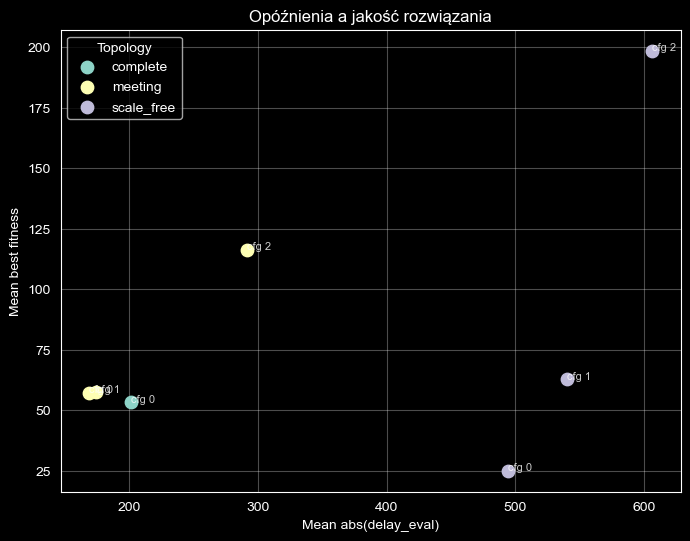

In [72]:
plt.figure(figsize=(8, 6))

for topology, group in summary_by_config.groupby("topology"):
    plt.scatter(
        group["mean_abs_delay_eval"],
        group["best_mean"],
        label=topology,
        s=80,
    )

    for _, row in group.iterrows():
        plt.annotate(
            f"cfg {int(row['config_id'])}",
            (row["mean_abs_delay_eval"], row["best_mean"]),
            fontsize=8,
            alpha=0.8,
        )

plt.xlabel("Mean abs(delay_eval)")
plt.ylabel("Mean best fitness")
plt.title("Opóźnienia a jakość rozwiązania")
plt.legend(title="Topology")
plt.grid(True, alpha=0.3)
plt.show()

# Najważniejsze obserwacje

- W ramach jednej topologii wyraźna korelacja między best fitness a abs(delay_eval)
- Pomiędzy topologiami nie - scale-free ma najlepsze wyniki i największe opóźnienia